 # Artificial Neural Networks (ANN)



Instructor: Amna Mazen

## Import libraries

In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.8 MB/s eta 0:00:00


In [2]:
import mglearn

import glob
import copy
import os, sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification, make_moons, make_circles


from keras.optimizers import SGD


from datetime import datetime
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
#from keras.utils.np_utils import to_categorical

## Helpful Customized Functions

In [29]:
def plot_data(X, y, figsize=None):
    if not figsize:
        figsize = (8, 6)
    plt.figure(figsize=figsize)
    plt.plot(X[y==0, 0], X[y==0, 1], 'or', alpha=0.5, label=0)
    plt.plot(X[y==1, 0], X[y==1, 1], 'ob', alpha=0.5, label=1)
    plt.xlim((min(X[:, 0])-0.1, max(X[:, 0])+0.1))
    plt.ylim((min(X[:, 1])-0.1, max(X[:, 1])+0.1))
    plt.legend()

def plot_loss_accuracy(history):
    historydf = pd.DataFrame(history.history, index=history.epoch)
    plt.figure(figsize=(8, 6))
    historydf.plot(ylim=(0, max(1, historydf.values.max())))
    loss = history.history['loss'][-1]
    acc = history.history['accuracy'][-1]
    plt.title('Loss: %.3f, Accuracy: %.3f' % (loss, acc))


def plot_decision_boundary(func, X, y, figsize=(9, 6)):
    amin, bmin = X.min(axis=0) - 0.1
    amax, bmax = X.max(axis=0) + 0.1
    hticks = np.linspace(amin, amax, 101)
    vticks = np.linspace(bmin, bmax, 101)

    aa, bb = np.meshgrid(hticks, vticks)
    ab = np.c_[aa.ravel(), bb.ravel()]
    c = func(ab)
    cc = c.reshape(aa.shape)

    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    fig, ax = plt.subplots(figsize=figsize)
    contour = plt.contourf(aa, bb, cc, cmap=cm, alpha=0.8)

    ax_c = fig.colorbar(contour)
    ax_c.set_label("$P(y = 1)$")
    ax_c.set_ticks([0, 0.25, 0.5, 0.75, 1])

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
    plt.xlim(amin, amax)
    plt.ylim(bmin, bmax)

def plot_confusion_matrix(model, X, y):
    y_pred = model.predict(X, verbose=0)>0.5
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(confusion_matrix(y, y_pred)), annot=True, fmt='d', cmap='YlGnBu', alpha=0.8, vmin=0)

## Introduction to neural networks

- Very popular these days under the name **deep learning**.
- Neural networks apply a sequence of transformations on your input data.
- They can be viewed a generalization of linear models where we apply a series of transformations.
- Here is graphical representation of a logistic regression model.
    - We have 4 features: x[0], x[1], x[2], x[3]

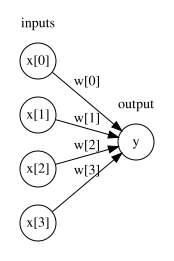

In [ ]:

mglearn.plots.plot_logistic_regression_graph()

- Below we are adding one "layer" of transformations in between features and the target.
- We are repeating the the process of computing the weighted sum multiple times.  
- The **hidden units** (e.g., h[1], h[2], ...) represent the intermediate processing steps.

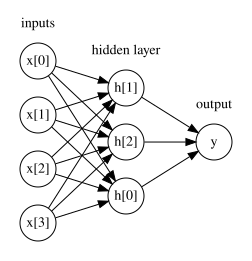

In [ ]:
mglearn.plots.plot_single_hidden_layer_graph()

- Now we are adding one more layer of transformations.

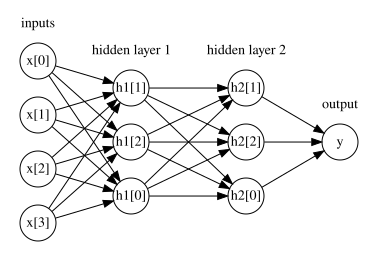

In [ ]:
mglearn.plots.plot_two_hidden_layer_graph()

- At a very high level you can also think of them as `Pipelines` in `sklearn`.
- A neural network is a model that's sort of like its own pipeline
  - It involves a series of transformations ("layers") internally.
  - The output is the prediction.

- To make them really powerful compared to the linear models, we apply a non-linear function to the weighted sum for each hidden node.

## Logistic Regression

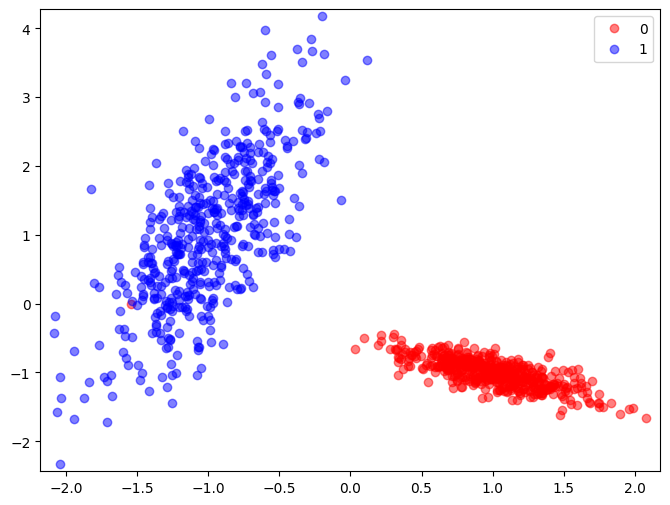

In [4]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_informative=2, random_state=7, n_clusters_per_class=1)
plot_data(X, y)

In [5]:
lr = LogisticRegression()
lr.fit(X, y)

LogisticRegression()

LR coefficients: [[-4.0747209   2.07498216]]
LR intercept: [-0.26598602]


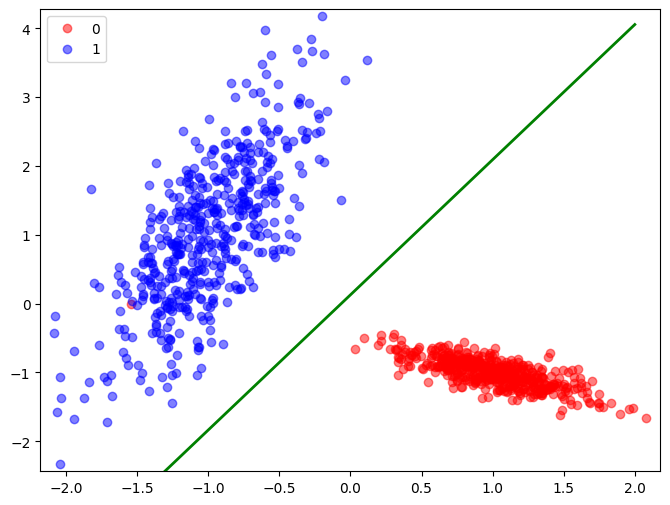

In [6]:
print('LR coefficients:', lr.coef_)
print('LR intercept:', lr.intercept_)

plot_data(X, y)

limits = np.array([-2, 2])
boundary = -(lr.coef_[0][0] * limits + lr.intercept_[0]) / lr.coef_[0][1]
plt.plot(limits, boundary, "g-", linewidth=2)

In [7]:

## Our first NN model
model = Sequential()
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Adam (Adaptive Moment Estimation) optimizer is used to adjust learning rates during training.
#It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.

history = model.fit(x=X, y=y, verbose=1, epochs=75) #The verbose parameter controls how much output you see while your model is training.
# verbose=0  Silent mode – No output at all.
# verbose=1 (Progress bar) – Shows a nice progress bar for each epoch with metrics.
# verbose=2 (One line per epoch) – Prints just one line of summary per epoch (less detailed).

Epoch 1/75


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1790 - loss: 1.0097
Epoch 2/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1880 - loss: 0.9694 
Epoch 3/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2020 - loss: 0.9306
Epoch 4/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2170 - loss: 0.8932
Epoch 5/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2640 - loss: 0.8573 
Epoch 6/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3230 - loss: 0.8228 
Epoch 7/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4040 - loss: 0.7894 
Epoch 8/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 0.7575 
Epoch 9/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5800 - loss: 0.7269 
Epoch 10/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6310 - loss: 0.6975 
Epoch 11/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6810 - loss: 0.6694 
Epoch 12/75
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7170 - loss:

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 3         
                                                                 
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


<Figure size 800x600 with 0 Axes>

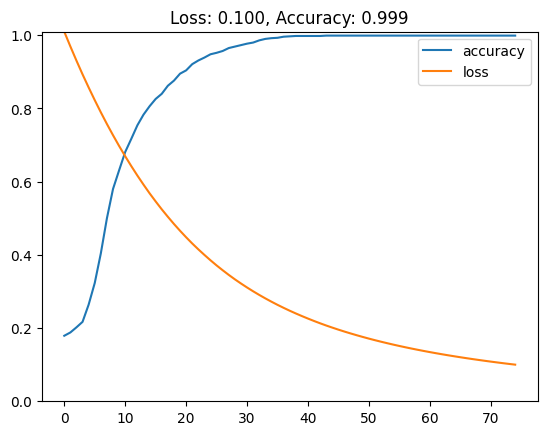

In [8]:
plot_loss_accuracy(history)

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


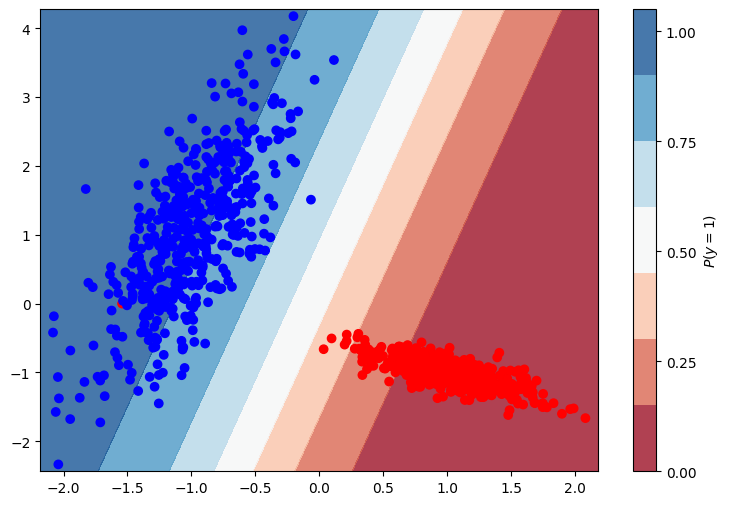

In [9]:
plot_decision_boundary(lambda x: model.predict(x), X, y)


In [10]:
y_pred = model.predict(X, verbose=0)>0.5

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       501
           1       1.00      1.00      1.00       499

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



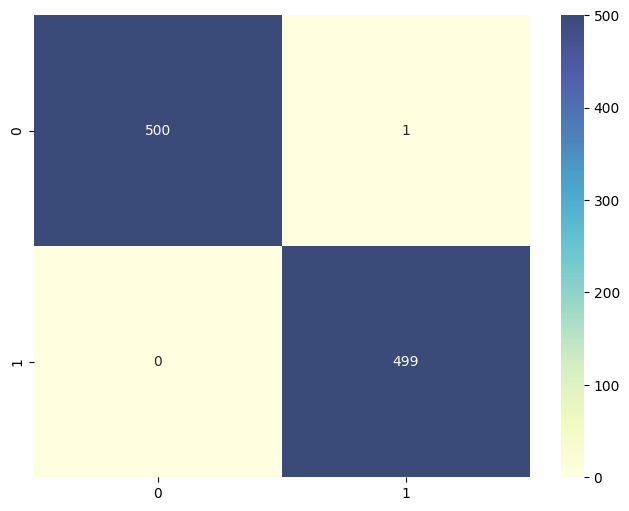

In [11]:
plot_confusion_matrix(model, X, y)


### Complex data - moons
The previous dataset was linearly separable, so it was trivial for our logistic regression model to separate the classes. Here is a more complex dataset which isn't linearly separable. The simple logistic regression model won't be able to distinguish between the classes.

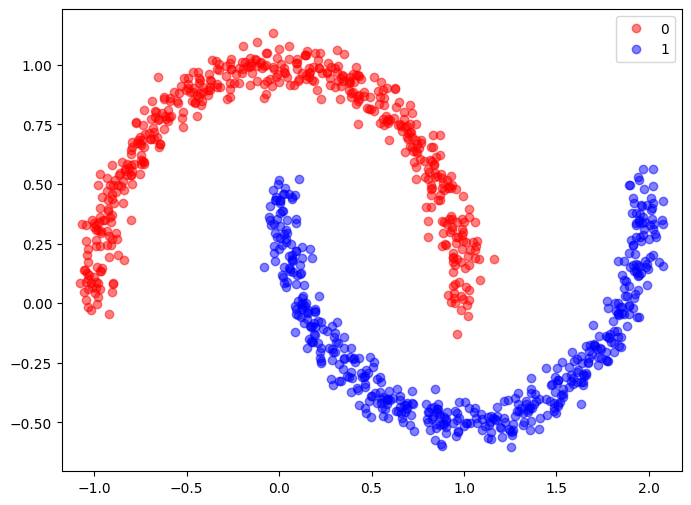

In [12]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)
plot_data(X, y)

We're building the another logistic regression model with the same parameters as we did before.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Figure size 800x600 with 0 Axes>

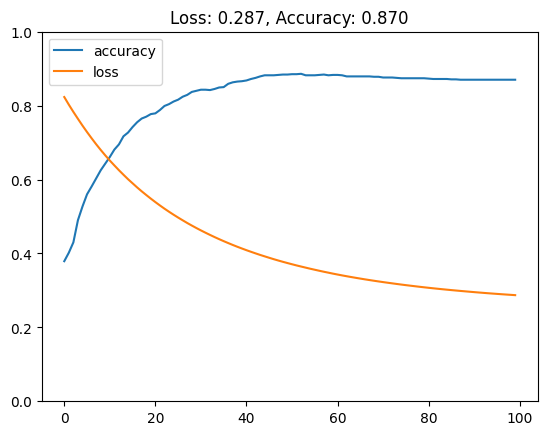

In [13]:
model = Sequential()
model.add(Dense(1, input_shape=(2,), activation='sigmoid'))

model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])
# Adam (Adaptive Moment Estimation) optimizer is used to adjust learning rates during training.
#It works well with large datasets and complex models because it uses memory efficiently and adapts the learning rate for each parameter automatically.

history = model.fit(X, y, verbose=0, epochs=100) #verbose=0 means Silent mode – No output at all.
plot_loss_accuracy(history)

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step


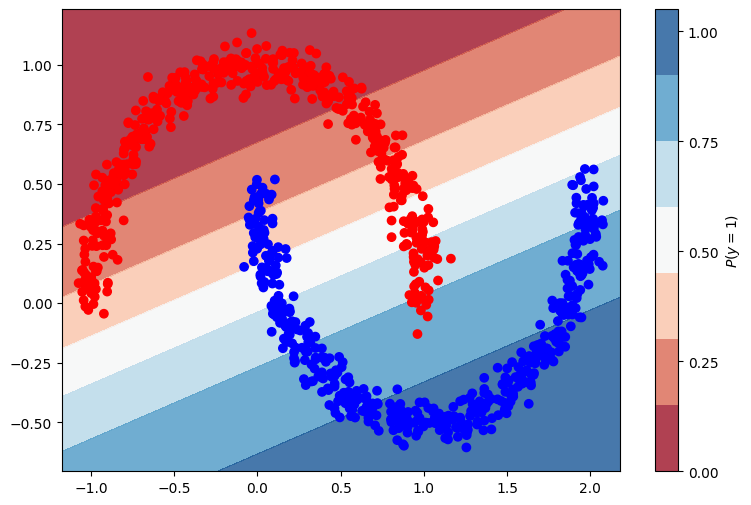

In [14]:
plot_decision_boundary(lambda x: model.predict(x), X, y)


Precision of the model is 86%. It looks good on paper but we should be able to get 100% with a more complex model. You can imagine a curved decision boundary that will separate out the classes, and a complex model should be able to approximate that.

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       500
           1       0.87      0.87      0.87       500

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



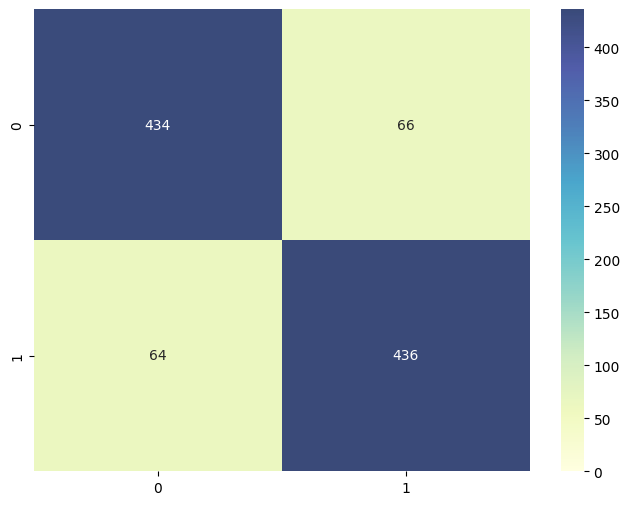

In [15]:
y_pred = model.predict(X, verbose=0)>0.5
print(classification_report(y, y_pred))
plot_confusion_matrix(model, X, y)

### Complex Data - Circles
Let's look at one final example where the liner model will fail.

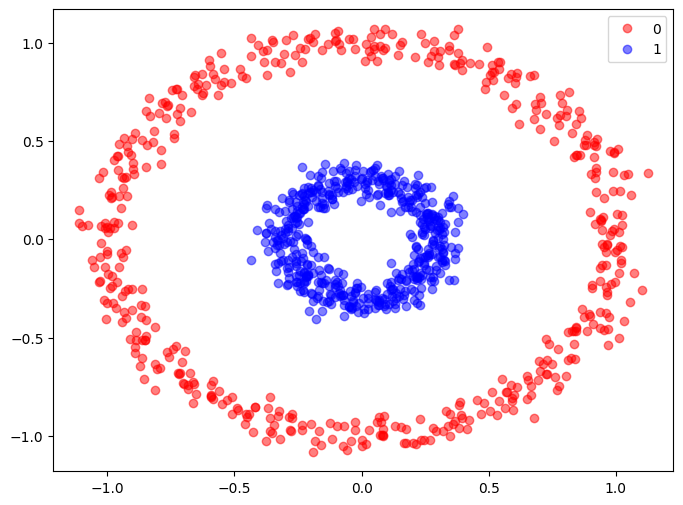

In [16]:
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.3, random_state=0)
plot_data(X, y)

Building the model with same parameters.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Figure size 800x600 with 0 Axes>

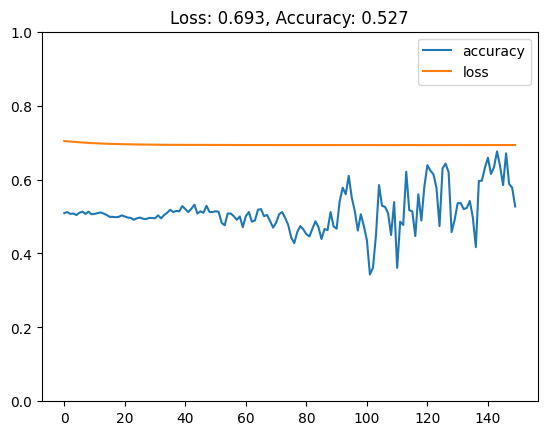

In [17]:
model = Sequential()
model.add(Dense(1, input_shape=(2,), activation='sigmoid'))

model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, verbose=0, epochs=150)
plot_loss_accuracy(history)

The decision boundary again passes from the middle of the data, but now we have much more misclassified points.



319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


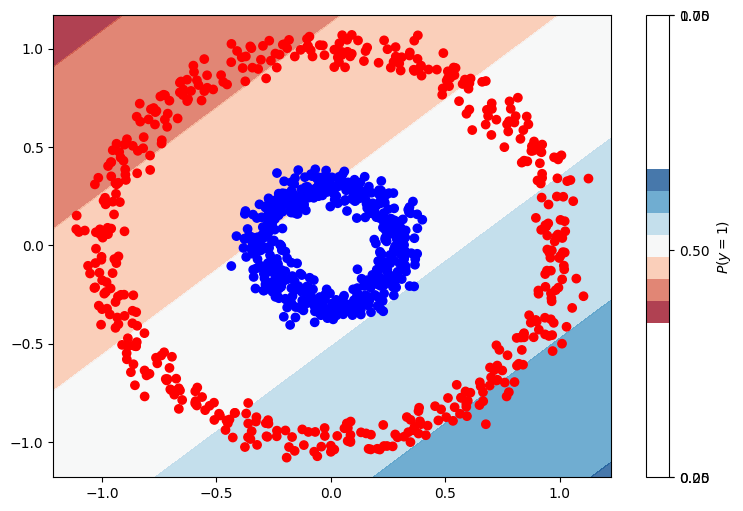

In [18]:
plot_decision_boundary(lambda x: model.predict(x), X, y)


The accuracy is 51%. **No matter where the model draws the linear line, it will misclassify half of the points, due to the nature of the dataset**.

The confusion matrix we see here is an example one belonging to a poor classifier. Ideally we want confusion matrices like the ones we saw above. High numbers along the diagonals meaning that the classifier was right, and low numbers everywhere else where the classifier was wrong. In our visualization, the color blue represents the high numbers and yellow represents the low ones. So we would prefer to see blue on the diagonals and yellow everywhere else, blues everywhere is a bad sign meaning that our classifier is confused.

              precision    recall  f1-score   support

           0       0.51      0.49      0.50       500
           1       0.51      0.54      0.53       500

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



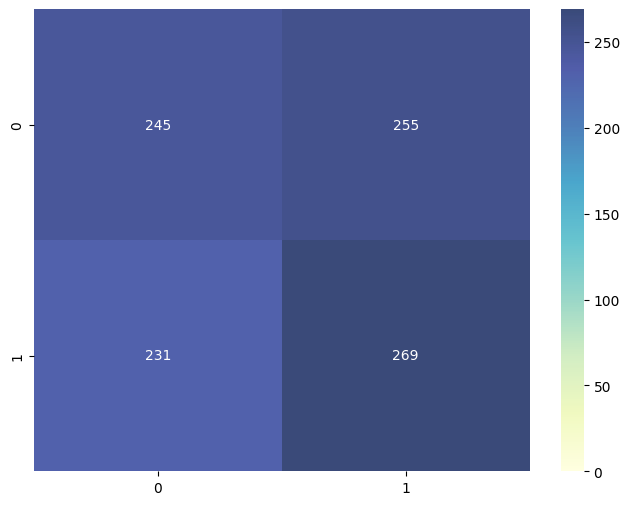

In [19]:
y_pred = model.predict(X, verbose=0)>0.5
print(classification_report(y, y_pred))
plot_confusion_matrix(model, X, y)

## Artificial Neural Networks (ANN)
Now we will train a deep Artificial Neural Networks (ANN) to better classify the datasets which the logistic regression model struggled, Moons and Circles.

While building Keras models for logistic regression above, we performed the following steps:

- Step 1: Define a Sequential model.
- Step 2: Add a Dense layer with sigmoid activation function. This was the only layer we needed.
- Step 3: Compile the model with an optimizer and loss function.
- Step 4: Fit the model to the dataset.
- Step 5: Analyze the results: plotting loss/accuracy curves, plotting the decision boundary, looking at the classification report, and understanding the confusion matrix.

While building a deep neural network, we only need to change step 2 such that, we will add several Dense layers one after another. The output of one layer becomes the input of the next. Keras again does most of the heavy lifting by initializing the weights and biases, and connecting the output of one layer to the input of the next. We only need to specify how many nodes we want in a given layer, and the activation function. It’s as simple as that.

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2600 - loss: 0.8159
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.6371
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8830 - loss: 0.4774
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8730 - loss: 0.3584
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8780 - loss: 0.3118
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8770 - loss: 0.2944
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8810 - loss: 0.2873
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8830 - loss: 0.2830
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8840 - loss: 0.2773
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8830 - loss: 0.2788
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8860 - loss: 0.2711
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

<Figure size 800x600 with 0 Axes>

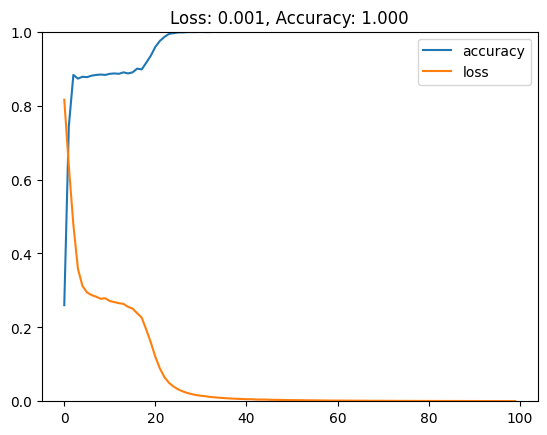

In [21]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)

model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='tanh')) #This layer has 4 neurons
model.add(Dense(2, activation='tanh')) #This layer has 2 neurons
model.add(Dense(1, activation='sigmoid'))

model.compile(Adam(learning_rate=0.01), 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, verbose=1, epochs=100)

plot_loss_accuracy(history)

In [22]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (312.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52 (212.00 B)

#### 📌 Parameter Calculation in Dense Layers

For a Dense (fully connected) layer, the number of parameters is calculated as:
$$
Parameters = (inputs \times neurons) + neurons
$$

- `inputs × neurons` = weights  
- `neurons` = biases  




## 📊 Applied to This Model

**Layer 1 (Input: 2 → Neurons: 4):**  
\[
(2 \times 4) + 4 = 12
\]

**Layer 2 (Input: 4 → Neurons: 2):**  
\[
(4 \times 2) + 2 = 10
\]

**Layer 3 (Input: 2 → Neurons: 1):**  
\[
(2 \times 1) + 1 = 3
\]



## ✅ Total Trainable Parameters

\[
12 + 10 + 3 = 25
\]



## ⚠️ Note

- **25** → Trainable model parameters  
- **52** → Optimizer parameters (Adam)  
- **77** → Total shown in summary  

Only the **trainable parameters (25)** are used during inference.

As you can see we first add a layer with 4 nodes and tanh activation function. Tanh is a commonly used activation function, and we'll learn more about it in another tutorial. We then add another layer with 2 nodes and again tanh activation. We finally add the last layer with 1 node and sigmoid activation. This is the final layer that we also used in the logistic regression model.

This is not a very deep ANN, it only has 3 layers: input layer, 1 hidden layer, and the output layer. But notice a couple of patterns:

Output layer still uses the sigmoid activation function since we're working on a binary classification problem.
Non-output layers use the tanh activation function. If we added more hidden layers, they would also have tanh activation.
We have fewer number of nodes in each subsequent layer. It's common to have less nodes as we stack layers on top of one another.
We didn't build a very deep ANN here because it wasn't necessary. We already achieve perfect accuracy with this configuration.

The ANN is able to come up with a perfect separator to distinguish the classes.



319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


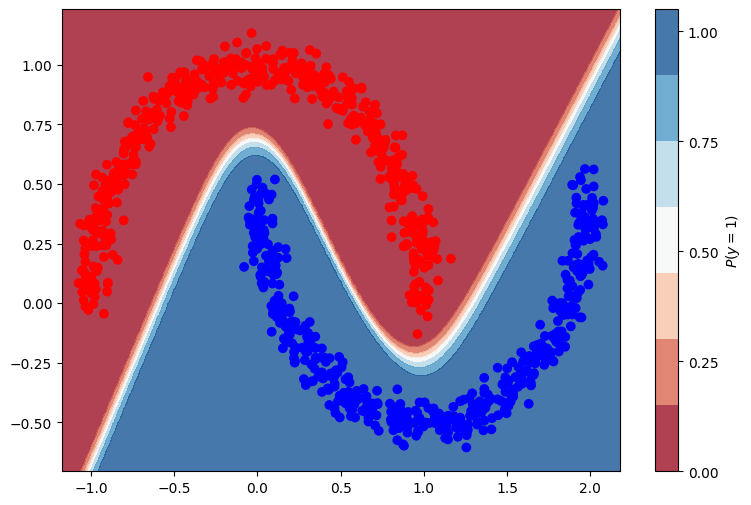

In [23]:
plot_decision_boundary(lambda x: model.predict(x), X, y)


100% precision, nothing misclassified.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



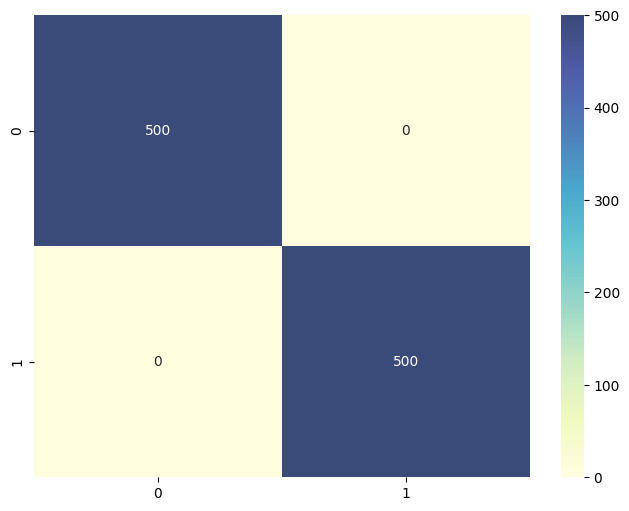

In [24]:
y_pred = model.predict(X, verbose=0)>0.5
print(classification_report(y, y_pred))
plot_confusion_matrix(model, X, y)

### Complex Data - Circles

Now let's look at the Circles dataset, where the LR model achieved only 50% accuracy. The model is the same as above, we only change the input to the fit function. And we again achieve 100% accuracy.

<Figure size 800x600 with 0 Axes>

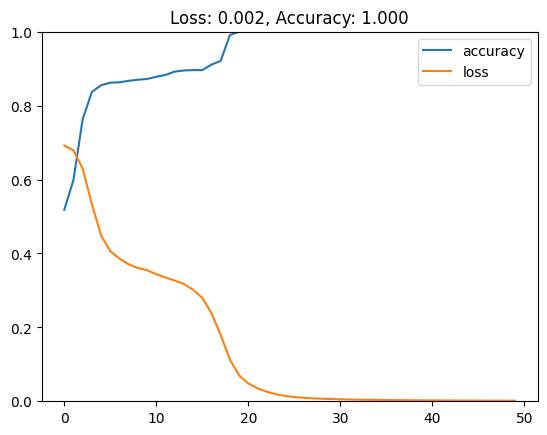

In [26]:
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.3, random_state=0)

model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(Adam(learning_rate=0.01), 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, verbose=0, epochs=50)

plot_loss_accuracy(history)

Similarly the decision boundary looks just like one we would draw by hand ourselves. The ANN was able to figure out an optimal separator.

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


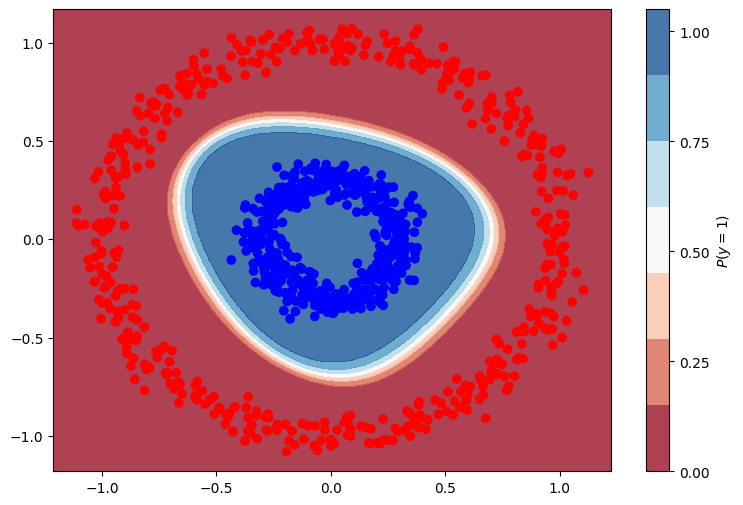

In [27]:
plot_decision_boundary(lambda x: model.predict(x), X, y)


Just like above we get 100% accuracy.



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



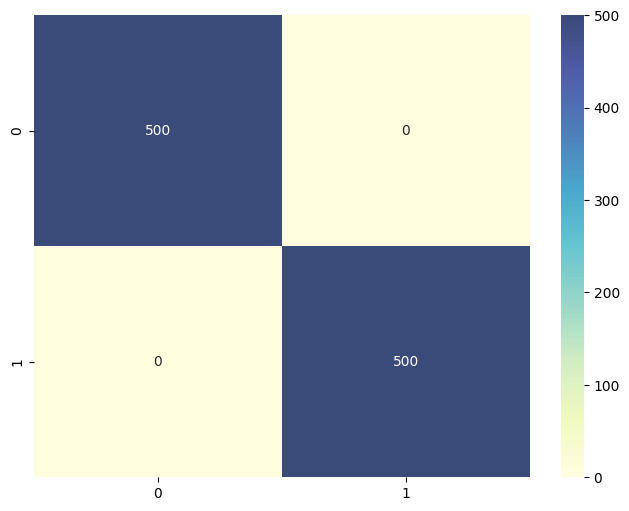

In [28]:
y_pred = model.predict(X, verbose=0)>0.5
print(classification_report(y, y_pred))
plot_confusion_matrix(model, X, y)